# EDA 

- Each stage holdout comes from the end of that stage.
- Training and holdout are separated by a complete 24-hour NF-only gap.
- Consecutive stages are separated by a complete 24-hour NF-only gap.
- Holdouts remain natural, unaugmented and unused during training.
- Holdouts are close to 15% in each stages.
- Each holdout contain enough FL and NF samples for meaningful evaluation.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

# Find the repository root.
ROOT = Path.cwd()

while not (ROOT / "data_labeling").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Repository root could not be found.")
    ROOT = ROOT.parent

LABEL_ROOT = ROOT / "data_labeling" / "data_labels"

OLD_LABELS = (
    LABEL_ROOT
    / "simplified_data_labels"
    / "labels_2010_2018_binary.csv"
)

NEW_LABELS = (
    LABEL_ROOT
    / "simplified_data_labels"
    / "labels_2019_2026_july_binary.csv"
)

REPAIR_LABELS = (
    LABEL_ROOT
    / "boundary_supplements"
    / "labels_boundary_repair_binary.csv"
)

OLD_CATALOGUE = (
    ROOT
    / "data_labeling"
    / "Catalogue"
    / "goes_flares_catalogue_2010_2018.csv"
)

NEW_CATALOGUE = (
    ROOT
    / "data_labeling"
    / "Catalogue"
    / "goes_flares_catalogue_2019_2026.csv"
)

for path in [
    OLD_LABELS,
    NEW_LABELS,
    REPAIR_LABELS,
    OLD_CATALOGUE,
    NEW_CATALOGUE,
]:
    assert path.exists(), f"File not found: {path}"

print("Repository:", ROOT)
print("All required files were found.")

Repository: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-
All required files were found.


In [2]:
# Load all binary labels
label_sources = {
    "2010–2018 labels": OLD_LABELS,
    "2019–2026 labels": NEW_LABELS,
    "December 31 repair": REPAIR_LABELS,
}

frames = []

for source_name, path in label_sources.items():
    frame = pd.read_csv(path)

    assert {"label", "goes_class"}.issubset(frame.columns)

    frame = frame[["label", "goes_class"]].copy()
    frame["source"] = source_name

    frames.append(frame)

raw_data = pd.concat(frames, ignore_index=True)

print("Rows before cleaning:", f"{len(raw_data):,}")
display(raw_data.head())

Rows before cleaning: 128,117


,label,goes_class,source
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010–2018 labels
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010–2018 labels
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010–2018 labels
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010–2018 labels
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010–2018 labels


In [3]:
timestamp_text = raw_data["label"].str.extract(
    r"HMI\.m(\d{4}\.\d{2}\.\d{2}_\d{2}\.\d{2}\.\d{2})"
)[0]

raw_data["timestamp"] = pd.to_datetime(
    timestamp_text,
    format="%Y.%m.%d_%H.%M.%S",
    errors="coerce",
)

raw_data["goes_class"] = pd.to_numeric(
    raw_data["goes_class"],
    errors="coerce",
)

In [4]:
data = (
    raw_data
    .sort_values(["timestamp", "source"])
    .drop_duplicates("label", keep="last")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

In [5]:
data

,label,goes_class,source,timestamp
0,2010/12/06/HMI.m2010.12.06_07.00.00.jpg,0,2010–2018 labels,2010-12-06 07:00:00
1,2010/12/06/HMI.m2010.12.06_08.00.00.jpg,0,2010–2018 labels,2010-12-06 08:00:00
2,2010/12/06/HMI.m2010.12.06_09.00.00.jpg,0,2010–2018 labels,2010-12-06 09:00:00
3,2010/12/06/HMI.m2010.12.06_10.00.00.jpg,0,2010–2018 labels,2010-12-06 10:00:00
4,2010/12/06/HMI.m2010.12.06_11.00.00.jpg,0,2010–2018 labels,2010-12-06 11:00:00
...,...,...,...,...
128112,2026/07/31/HMI.m2026.07.31_19.00.00.jpg,0,2019–2026 labels,2026-07-31 19:00:00
128113,2026/07/31/HMI.m2026.07.31_20.00.00.jpg,0,2019–2026 labels,2026-07-31 20:00:00
128114,2026/07/31/HMI.m2026.07.31_21.00.00.jpg,0,2019–2026 labels,2026-07-31 21:00:00
128115,2026/07/31/HMI.m2026.07.31_22.00.00.jpg,0,2019–2026 labels,2026-07-31 22:00:00


In [6]:

print("First observation:", data["timestamp"].min())
print("Last observation:", data["timestamp"].max())

First observation: 2010-12-06 07:00:00
Last observation: 2026-07-31 23:00:00


Yearly data distribution

In [7]:
data["year"] = data["timestamp"].dt.year

yearly_summary = (
    data.groupby("year")["goes_class"]
    .agg(samples="size", FL="sum")
)

yearly_summary["NF"] = (
    yearly_summary["samples"] - yearly_summary["FL"]
)

yearly_summary["FL_percent"] = (
    100 * yearly_summary["FL"] / yearly_summary["samples"]
)

display(yearly_summary)

,samples,FL,NF,FL_percent
year,,,,
2010,562,0,562,0.000000
2011,6528,1235,5293,18.918505
2012,6516,1358,5158,20.841007
2013,7656,1436,6220,18.756531
2014,8405,2702,5703,32.147531
2015,8511,1664,6847,19.551169
2016,8337,250,8087,2.998681
2017,8377,330,8047,3.939358
2018,8417,0,8417,0.000000


Define the proposed chronological design

In [8]:
BLOCK_LIMITS = {
    "Stage 1 complete": (
        pd.Timestamp("2010-12-06 07:00:00"),
        pd.Timestamp("2017-12-31 23:00:00"),
    ), 
    "Stage 2 complete": (
        pd.Timestamp("2018-01-02 00:00:00"),
        pd.Timestamp("2023-06-29 22:00:00"),
    ),
    "Stage 3 complete": (
        pd.Timestamp("2023-06-30 23:00:00"),
        pd.Timestamp("2024-06-29 10:00:00"),
    ),
    "Validation": (
        pd.Timestamp("2024-06-30 11:00:00"),
        pd.Timestamp("2025-06-30 23:00:00"),
    ),
    "Test": (
        pd.Timestamp("2025-07-02 00:00:00"),
        pd.Timestamp("2026-07-31 23:00:00"),
    ),
}

In [9]:
MAJOR_GAPS = {
    "Stage 1 → Stage 2": (
        pd.Timestamp("2018-01-01 00:00:00"),
        pd.Timestamp("2018-01-01 23:00:00"),
    ),
    "Stage 2 → Stage 3": (
        pd.Timestamp("2023-06-29 23:00:00"),
        pd.Timestamp("2023-06-30 22:00:00"),
    ),
    "Stage 3 → Validation": (
        pd.Timestamp("2024-06-29 11:00:00"),
        pd.Timestamp("2024-06-30 10:00:00"),
    ),
    "Validation → Test": (
        pd.Timestamp("2025-07-01 00:00:00"),
        pd.Timestamp("2025-07-01 23:00:00"),
    ),
}

In [10]:
design_table = []

for name, (start, end) in BLOCK_LIMITS.items():
    design_table.append({
        "period": name,
        "type": "Data",
        "start": start,
        "end": end,
    })


In [11]:
for name, (start, end) in MAJOR_GAPS.items():
    design_table.append({
        "period": name,
        "type": "24-hour NF gap",
        "start": start,
        "end": end,
    })

design_table = (
    pd.DataFrame(design_table)
    .sort_values("start")
    .reset_index(drop=True)
)


In [12]:

display(design_table)

,period,type,start,end
0,Stage 1 complete,Data,2010-12-06 07:00:00,2017-12-31 23:00:00
1,Stage 1 → Stage 2,24-hour NF gap,2018-01-01 00:00:00,2018-01-01 23:00:00
2,Stage 2 complete,Data,2018-01-02 00:00:00,2023-06-29 22:00:00
3,Stage 2 → Stage 3,24-hour NF gap,2023-06-29 23:00:00,2023-06-30 22:00:00
4,Stage 3 complete,Data,2023-06-30 23:00:00,2024-06-29 10:00:00
5,Stage 3 → Validation,24-hour NF gap,2024-06-29 11:00:00,2024-06-30 10:00:00
6,Validation,Data,2024-06-30 11:00:00,2025-06-30 23:00:00
7,Validation → Test,24-hour NF gap,2025-07-01 00:00:00,2025-07-01 23:00:00
8,Test,Data,2025-07-02 00:00:00,2026-07-31 23:00:00


Validates that the buffer gaps strictly adhere to safety rules.

Verifies that every gap contains exactly 24 hours of observations, has $0$ flare samples ($\text{FL} = 0$), and has no missing hourly entries (valid_gap == True).

In [13]:
major_gap_rows = []

for gap_name, (gap_start, gap_end) in MAJOR_GAPS.items():
    gap_data = data[
        data["timestamp"].between(gap_start, gap_end)
    ].copy()

    expected_hours = pd.date_range(
        gap_start,
        gap_end,
        freq="h",
    )

    missing_hours = expected_hours.difference(
        gap_data["timestamp"]
    )

    fl = int(gap_data["goes_class"].sum())
    nf = len(gap_data) - fl

    major_gap_rows.append({
        "boundary": gap_name,
        "gap_start": gap_start,
        "gap_end": gap_end,
        "samples": len(gap_data),
        "FL": fl,
        "NF": nf,
        "missing_hours": len(missing_hours),
        "valid_gap": (
            len(gap_data) == 24
            and fl == 0
            and len(missing_hours) == 0
        ),
    })

major_gap_summary = pd.DataFrame(major_gap_rows)

display(major_gap_summary)

assert major_gap_summary["valid_gap"].all()

print("All major boundaries contain a complete 24-hour NF-only gap.")

,boundary,gap_start,gap_end,samples,FL,NF,missing_hours,valid_gap
0,Stage 1 → Stage 2,2018-01-01 00:00:00,2018-01-01 23:00:00,24,0,24,0,True
1,Stage 2 → Stage 3,2023-06-29 23:00:00,2023-06-30 22:00:00,24,0,24,0,True
2,Stage 3 → Validation,2024-06-29 11:00:00,2024-06-30 10:00:00,24,0,24,0,True
3,Validation → Test,2025-07-01 00:00:00,2025-07-01 23:00:00,24,0,24,0,True


All major boundaries contain a complete 24-hour NF-only gap.


report generator


In [14]:
def summarize_period(name, frame, planned_start=None, planned_end=None):
    # 1. Counts the total number of actual rows/observations present in the input DataFrame
    total = len(frame)
    
    # 2. Sums all binary flare labels (1 for FL, 0 for NF) to get the total number of flare samples
    fl = int(frame["goes_class"].sum())
    
    # 3. Calculates no-flare (NF) samples by subtracting flare samples from total samples
    nf = total - fl

    # 4. Extracts the earliest and latest timestamps physically present in the DataFrame slice
    actual_start = frame["timestamp"].min()
    actual_end = frame["timestamp"].max()

    # 5. Uses planned start/end dates if provided; otherwise, falls back to actual timestamps
    start = planned_start if planned_start is not None else actual_start
    end = planned_end if planned_end is not None else actual_end

    # 6. Calculates the total expected hourly timestamps between the target start and end dates
    expected_hours = (
        int((end - start) / pd.Timedelta(hours=1)) + 1
        if pd.notna(start) and pd.notna(end)
        else 0
    )

    # 7. Constructs and returns a dictionary summarizing all period health and class metrics
    return {
        "dataset": name,
        "planned_start": start,
        "planned_end": end,
        "actual_start": actual_start,
        "actual_end": actual_end,
        "samples": total,
        "expected_hours": expected_hours,
        "missing_hours": expected_hours - total, # Number of dropped/missing hourly image frames
        "coverage_percent": (
            100 * total / expected_hours         # Percentage of complete data received vs. expected
            if expected_hours > 0
            else np.nan
        ),
        "FL": fl,                                # Count of Flare samples
        "NF": nf,                                # Count of No-Flare samples
        "FL_percent": (
            100 * fl / total                     # Percentage of dataset containing positive flare labels
            if total > 0
            else np.nan
        ),
    }

In [15]:
complete_blocks = {}

for name, (start, end) in BLOCK_LIMITS.items():
    complete_blocks[name] = data[
        data["timestamp"].between(start, end)
    ].copy()

stage1_complete = complete_blocks["Stage 1 complete"]
stage2_complete = complete_blocks["Stage 2 complete"]
stage3_complete = complete_blocks["Stage 3 complete"]
validation_data = complete_blocks["Validation"]
test_data = complete_blocks["Test"]

complete_summary = pd.DataFrame([
    summarize_period(
        name,
        complete_blocks[name],
        planned_start=BLOCK_LIMITS[name][0],
        planned_end=BLOCK_LIMITS[name][1],
    )
    for name in BLOCK_LIMITS
])

display(complete_summary)

,dataset,planned_start,planned_end,actual_start,actual_end,samples,expected_hours,missing_hours,coverage_percent,FL,NF,FL_percent
0,Stage 1 complete,2010-12-06 07:00:00,2017-12-31 23:00:00,2010-12-06 07:00:00,2017-12-31 23:00:00,54892,61985,7093,88.556909,8975,45917,16.350288
1,Stage 2 complete,2018-01-02 00:00:00,2023-06-29 22:00:00,2018-01-02 00:00:00,2023-06-29 22:00:00,46800,48119,1319,97.258879,4865,41935,10.395299
2,Stage 3 complete,2023-06-30 23:00:00,2024-06-29 10:00:00,2023-06-30 23:00:00,2024-06-29 10:00:00,8649,8748,99,98.868313,3929,4720,45.427217
3,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,8773,280,96.808389,4142,4351,48.769575
4,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,9480,293,96.909283,3018,6169,32.850767


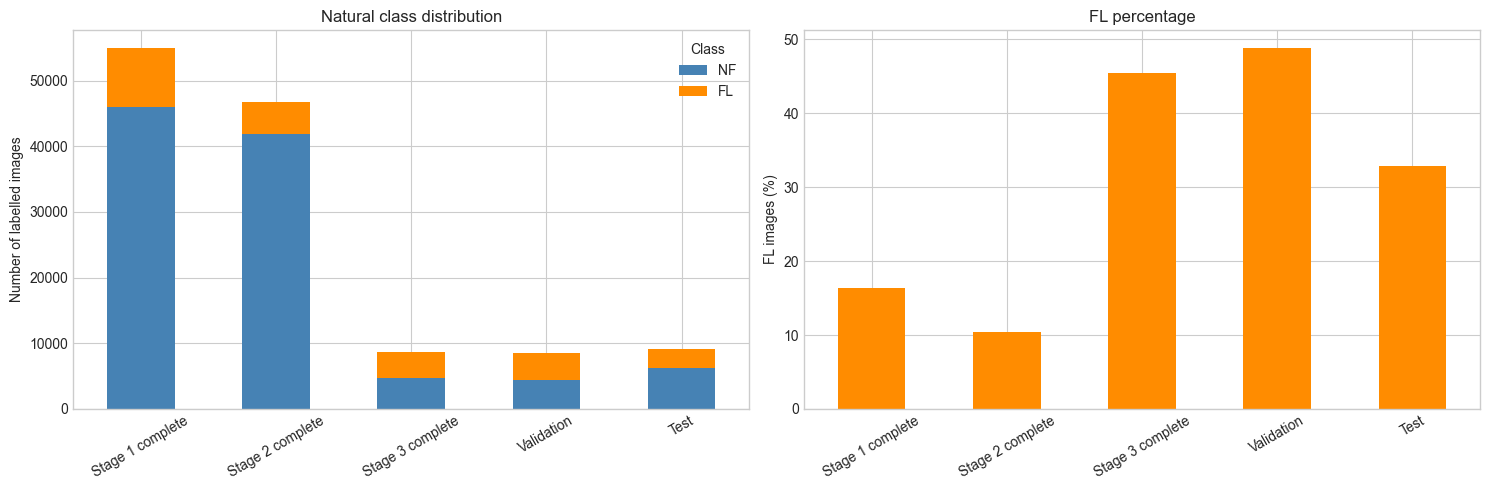

In [16]:
plot_summary = complete_summary.set_index("dataset")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

plot_summary[["NF", "FL"]].plot(
    kind="bar",
    stacked=True,
    color=["steelblue", "darkorange"],
    ax=axes[0],
)

axes[0].set_title("Natural class distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of labelled images")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Class")

plot_summary["FL_percent"].plot(
    kind="bar",
    color="darkorange",
    ax=axes[1],
)

axes[1].set_title("FL percentage")
axes[1].set_xlabel("")
axes[1].set_ylabel("FL images (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [17]:
def find_holdout_candidates(
    stage_data, target_fraction=0.15, minimum_fl=200, minimum_nf=200
):
    """Find possible end-holdouts for one stage with a 24h NF gap."""
    # 1. Sort data chronologically and build a complete hourly index
    stage_data = stage_data.sort_values("timestamp").reset_index(drop=True)
    full_hourly_index = pd.date_range(
        stage_data["timestamp"].min(), stage_data["timestamp"].max(), freq="h"
    )
    hourly_labels = (
        stage_data.set_index("timestamp")["goes_class"].reindex(
            full_hourly_index
        )
    )

    # 2. Identify 24-hour windows with zero missing data and zero flares
    # Looking back at the preceding 24 hours FOR EACH timestamp to identify clean gaps.
    rolling_count = hourly_labels.rolling(24).count()
    rolling_fl = hourly_labels.rolling(24).sum()
    # Collects all timestamps where a 24-hour clean gap ends.
    valid_gap_ends = hourly_labels.index[
        (rolling_count == 24) & (rolling_fl == 0)
    ]

    # 3. Evaluate each valid gap split against size and class requirements
    stage_fl_percent = 100 * stage_data["goes_class"].mean() #Computes the overall flare ratio of the whole stage.
    candidates = []

    for gap_end in valid_gap_ends:
        gap_start = gap_end - pd.Timedelta(hours=23)
        holdout_start = gap_end + pd.Timedelta(hours=1)

        training = stage_data[stage_data["timestamp"] < gap_start]
        holdout = stage_data[stage_data["timestamp"] >= holdout_start]

        if training.empty or holdout.empty:
            continue

        holdout_fl = int(holdout["goes_class"].sum())
        holdout_nf = len(holdout) - holdout_fl

        if holdout_fl < minimum_fl or holdout_nf < minimum_nf:
            continue

        retained_samples = len(training) + len(holdout)
        holdout_fraction = len(holdout) / retained_samples
        holdout_fl_percent = 100 * holdout_fl / len(holdout)

        candidates.append(
            {
                "gap_start": gap_start,
                "gap_end": gap_end,
                "train_end": training["timestamp"].max(),
                "holdout_start": holdout["timestamp"].min(),
                "holdout_end": holdout["timestamp"].max(),
                "train_samples": len(training),
                "holdout_samples": len(holdout),
                "holdout_FL": holdout_fl,
                "holdout_NF": holdout_nf,
                "holdout_percent": 100 * holdout_fraction,
                "holdout_FL_percent": holdout_fl_percent,
                "stage_FL_percent": stage_fl_percent,
                "class_shift_points": abs(
                    holdout_fl_percent - stage_fl_percent
                ),
                "size_error_points": abs(
                    100 * holdout_fraction - 100 * target_fraction
                ),
            }
        )

    # 4. Rank candidates by size match, distribution match, and start time
    candidates = pd.DataFrame(candidates)
    if candidates.empty:
        raise ValueError("No holdout satisfies the requested requirements.")

    return candidates.sort_values(
        ["size_error_points", "class_shift_points", "gap_start"]
    ).reset_index(drop=True)

- size_error_points: Measures how far the candidate holdout's actual size percentage is from our target size (15%), prioritizing splits that closely match the planned train/test ratio.

- class_shift_points: Measures the difference in flare percentage between the holdout set and the full stage data, favoring splits that prevent class distribution imbalance.

- gap_start: Identifies the starting timestamp of the 24-hour buffer gap,  by selecting the earlier split when size and class metrics are identical.

In [18]:
stage_complete_sets = {
    "Stage 1": stage1_complete,
    "Stage 2": stage2_complete,
    "Stage 3": stage3_complete,
}

candidate_tables = {}

candidate_columns = [
    "gap_start",
    "gap_end",
    "train_samples",
    "holdout_samples",
    "holdout_FL",
    "holdout_NF",
    "holdout_percent",
    "holdout_FL_percent",
    "stage_FL_percent",
    "class_shift_points",
    "size_error_points",
]

for stage_name, stage_frame in stage_complete_sets.items():
    candidates = find_holdout_candidates(stage_frame)
    candidate_tables[stage_name] = candidates

    print(f"\n{stage_name}: five best candidates")
    display(candidates[candidate_columns].head(5))


Stage 1: five best candidates


,gap_start,gap_end,train_samples,holdout_samples,holdout_FL,holdout_NF,holdout_percent,holdout_FL_percent,stage_FL_percent,class_shift_points,size_error_points
0,2017-01-06 04:00:00,2017-01-07 03:00:00,46638,8230,330,7900,14.999635,4.009721,16.350288,12.340567,0.000365
1,2017-01-06 03:00:00,2017-01-07 02:00:00,46637,8231,330,7901,15.001458,4.009233,16.350288,12.341054,0.001458
2,2017-01-06 05:00:00,2017-01-07 04:00:00,46639,8229,330,7899,14.997813,4.010208,16.350288,12.340080,0.002187
3,2017-01-06 02:00:00,2017-01-07 01:00:00,46636,8232,330,7902,15.003281,4.008746,16.350288,12.341541,0.003281
4,2017-01-06 06:00:00,2017-01-07 05:00:00,46640,8228,330,7898,14.995990,4.010695,16.350288,12.339593,0.004010



Stage 2: five best candidates


,gap_start,gap_end,train_samples,holdout_samples,holdout_FL,holdout_NF,holdout_percent,holdout_FL_percent,stage_FL_percent,class_shift_points,size_error_points
0,2022-09-06 00:00:00,2022-09-06 23:00:00,39760,7016,2870,4146,14.999145,40.906499,10.395299,30.511200,0.000855
1,2022-09-05 23:00:00,2022-09-06 22:00:00,39759,7017,2870,4147,15.001283,40.900670,10.395299,30.505371,0.001283
2,2022-09-06 01:00:00,2022-09-07 00:00:00,39761,7015,2870,4145,14.997007,40.912331,10.395299,30.517032,0.002993
3,2022-09-05 22:00:00,2022-09-06 21:00:00,39758,7018,2870,4148,15.003421,40.894842,10.395299,30.499543,0.003421
4,2022-09-06 02:00:00,2022-09-07 01:00:00,39762,7014,2870,4144,14.994869,40.918164,10.395299,30.522865,0.005131



Stage 3: five best candidates


,gap_start,gap_end,train_samples,holdout_samples,holdout_FL,holdout_NF,holdout_percent,holdout_FL_percent,stage_FL_percent,class_shift_points,size_error_points
0,2024-05-06 06:00:00,2024-05-07 05:00:00,7352,1273,814,459,14.759420,63.943441,45.427217,18.516224,0.240580
1,2024-05-06 07:00:00,2024-05-07 06:00:00,7353,1272,814,458,14.747826,63.993711,45.427217,18.566494,0.252174
2,2024-05-06 08:00:00,2024-05-07 07:00:00,7354,1271,814,457,14.736232,64.044060,45.427217,18.616843,0.263768
3,2024-05-06 09:00:00,2024-05-07 08:00:00,7355,1270,814,456,14.724638,64.094488,45.427217,18.667271,0.275362
4,2024-05-06 10:00:00,2024-05-07 09:00:00,7356,1269,814,455,14.713043,64.144996,45.427217,18.717779,0.286957


In [19]:
selected_splits = {}

for stage_name, stage_frame in stage_complete_sets.items():
    # 1. Select the top-ranked candidate and retrieve timestamps
    selected = candidate_tables[stage_name].iloc[0]
    gap_start = selected["gap_start"]
    gap_end = selected["gap_end"]
    holdout_start = selected["holdout_start"]

    # 2. Slice dataset into training, 24h buffer gap, and holdout sets
    training = stage_frame[stage_frame["timestamp"] < gap_start].copy()
    internal_gap = stage_frame[stage_frame["timestamp"].between(gap_start, gap_end)].copy()
    holdout = stage_frame[stage_frame["timestamp"] >= holdout_start].copy()

    # 3. Store split dataframes and gap metadata
    selected_splits[stage_name] = {
        "training": training,
        "gap": internal_gap,
        "holdout": holdout,
        "gap_start": gap_start,
        "gap_end": gap_end,
    }

print("Highest-ranked holdout candidate selected for each stage.")

Highest-ranked holdout candidate selected for each stage.


In [20]:
split_rows = []

# 1. Iterate through stage splits and summarize Train, Gap, and Holdout sets
for stage_name, split in selected_splits.items():
    training, gap, holdout = split["training"], split["gap"], split["holdout"]

    # Summarize individual subsets and assign dataset roles
    train_row = summarize_period(f"{stage_name} train", training)
    train_row["role"] = "Train"

    gap_row = summarize_period(
        f"{stage_name} internal gap", gap,
        planned_start=split["gap_start"], planned_end=split["gap_end"]
    )
    gap_row["role"] = "NF gap"

    holdout_row = summarize_period(f"{stage_name} holdout", holdout)
    holdout_row["role"] = "Holdout"

    # Compute holdout percentage relative to retained (Train + Holdout) samples
    retained = len(training) + len(holdout)
    train_row["holdout_percent"] = np.nan
    gap_row["holdout_percent"] = np.nan
    holdout_row["holdout_percent"] = 100 * len(holdout) / retained

    split_rows.extend([train_row, gap_row, holdout_row])

# 2. Build summary DataFrame and display selected key metrics
split_summary = pd.DataFrame(split_rows)
display_columns = [
    "dataset", "role", "actual_start", "actual_end",
    "samples", "FL", "NF", "FL_percent", "holdout_percent"
]
display(split_summary[display_columns])

,dataset,role,actual_start,actual_end,samples,FL,NF,FL_percent,holdout_percent
0,Stage 1 train,Train,2010-12-06 07:00:00,2017-01-06 03:00:00,46638,8645,37993,18.536387,NaN
1,Stage 1 internal gap,NF gap,2017-01-06 04:00:00,2017-01-07 03:00:00,24,0,24,0.000000,NaN
2,Stage 1 holdout,Holdout,2017-01-07 04:00:00,2017-12-31 23:00:00,8230,330,7900,4.009721,14.999635
3,Stage 2 train,Train,2018-01-02 00:00:00,2022-09-05 23:00:00,39760,1995,37765,5.017606,NaN
4,Stage 2 internal gap,NF gap,2022-09-06 00:00:00,2022-09-06 23:00:00,24,0,24,0.000000,NaN
5,Stage 2 holdout,Holdout,2022-09-07 00:00:00,2023-06-29 22:00:00,7016,2870,4146,40.906499,14.999145
6,Stage 3 train,Train,2023-06-30 23:00:00,2024-05-06 05:00:00,7352,3115,4237,42.369423,NaN
7,Stage 3 internal gap,NF gap,2024-05-06 06:00:00,2024-05-07 05:00:00,24,0,24,0.000000,NaN
8,Stage 3 holdout,Holdout,2024-05-07 06:00:00,2024-06-29 10:00:00,1273,814,459,63.943441,14.759420


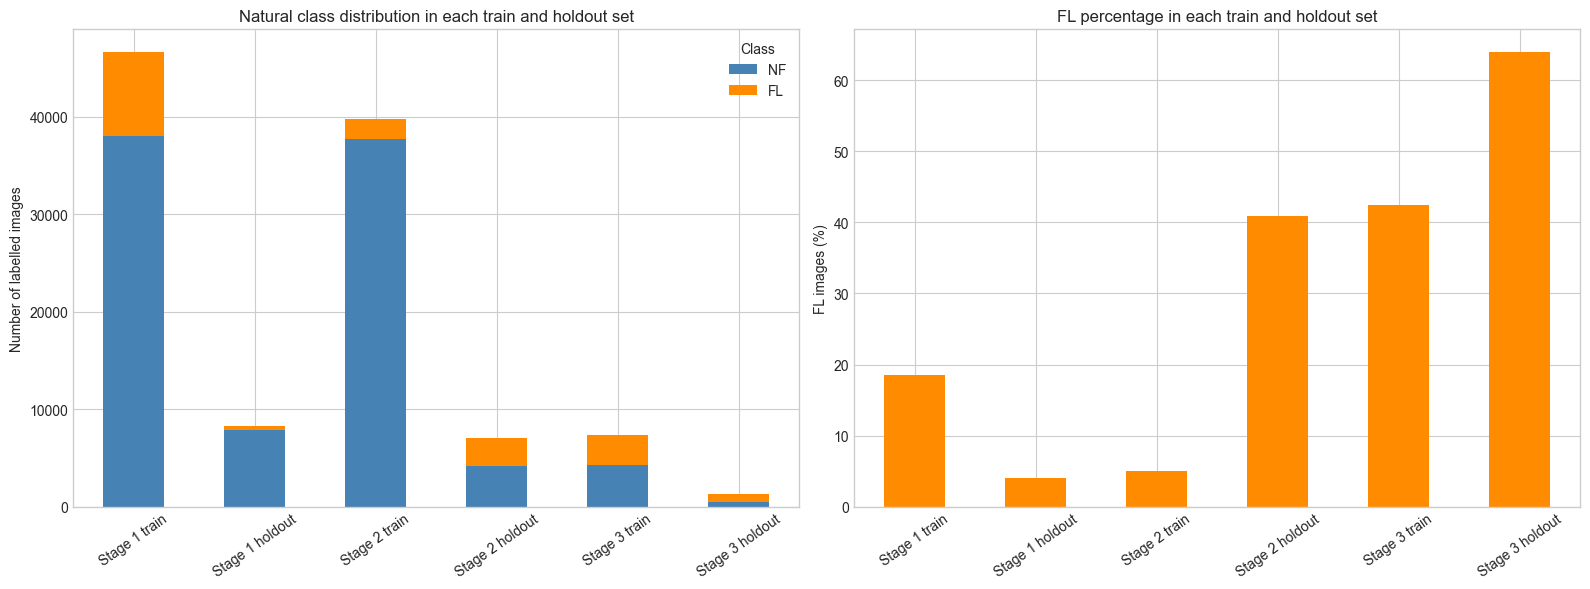

In [21]:
train_holdout_summary = split_summary[
    split_summary["role"].isin(["Train", "Holdout"])
].copy()

plot_frame = (
    train_holdout_summary
    .set_index("dataset")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

plot_frame[["NF", "FL"]].plot(
    kind="bar",
    stacked=True,
    color=["steelblue", "darkorange"],
    ax=axes[0],
)

axes[0].set_title(
    "Natural class distribution in each train and holdout set"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of labelled images")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="Class")

plot_frame["FL_percent"].plot(
    kind="bar",
    color="darkorange",
    ax=axes[1],
)

axes[1].set_title("FL percentage in each train and holdout set")
axes[1].set_xlabel("")
axes[1].set_ylabel("FL images (%)")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [22]:
future_summary = pd.DataFrame([
    summarize_period(
        "Validation",
        validation_data,
        planned_start=BLOCK_LIMITS["Validation"][0],
        planned_end=BLOCK_LIMITS["Validation"][1],
    ),
    summarize_period(
        "Test",
        test_data,
        planned_start=BLOCK_LIMITS["Test"][0],
        planned_end=BLOCK_LIMITS["Test"][1],
    ),
])

display(future_summary[[
    "dataset",
    "planned_start",
    "planned_end",
    "samples",
    "missing_hours",
    "coverage_percent",
    "FL",
    "NF",
    "FL_percent",
]])

,dataset,planned_start,planned_end,samples,missing_hours,coverage_percent,FL,NF,FL_percent
0,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,280,96.808389,4142,4351,48.769575
1,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,293,96.909283,3018,6169,32.850767


In [23]:
final_design_rows = []

for stage_name, split in selected_splits.items():
    training = split["training"]
    holdout = split["holdout"]

    final_design_rows.append({
        "dataset": f"{stage_name} train",
        "start": training["timestamp"].min(),
        "end": training["timestamp"].max(),
        "samples": len(training),
        "FL": int(training["goes_class"].sum()),
        "NF": int((training["goes_class"] == 0).sum()),
    })

    final_design_rows.append({
        "dataset": f"{stage_name} holdout",
        "start": holdout["timestamp"].min(),
        "end": holdout["timestamp"].max(),
        "samples": len(holdout),
        "FL": int(holdout["goes_class"].sum()),
        "NF": int((holdout["goes_class"] == 0).sum()),
    })

for name, frame in [
    ("Validation", validation_data),
    ("Test", test_data),
]:
    final_design_rows.append({
        "dataset": name,
        "start": frame["timestamp"].min(),
        "end": frame["timestamp"].max(),
        "samples": len(frame),
        "FL": int(frame["goes_class"].sum()),
        "NF": int((frame["goes_class"] == 0).sum()),
    })

final_design = pd.DataFrame(final_design_rows)

final_design["FL_percent"] = (
    100 * final_design["FL"] / final_design["samples"]
)

display(final_design)

,dataset,start,end,samples,FL,NF,FL_percent
0,Stage 1 train,2010-12-06 07:00:00,2017-01-06 03:00:00,46638,8645,37993,18.536387
1,Stage 1 holdout,2017-01-07 04:00:00,2017-12-31 23:00:00,8230,330,7900,4.009721
2,Stage 2 train,2018-01-02 00:00:00,2022-09-05 23:00:00,39760,1995,37765,5.017606
3,Stage 2 holdout,2022-09-07 00:00:00,2023-06-29 22:00:00,7016,2870,4146,40.906499
4,Stage 3 train,2023-06-30 23:00:00,2024-05-06 05:00:00,7352,3115,4237,42.369423
5,Stage 3 holdout,2024-05-07 06:00:00,2024-06-29 10:00:00,1273,814,459,63.943441
6,Validation,2024-06-30 11:00:00,2025-06-30 23:00:00,8493,4142,4351,48.769575
7,Test,2025-07-02 00:00:00,2026-07-31 23:00:00,9187,3018,6169,32.850767


- Holdouts are selected chronologically from the end of each stage.
- Each training–holdout boundary contains a complete 24-hour NF-only gap.
- Every major dataset boundary contains a complete 24-hour NF-only gap.
- Stage 1 and Stage 2 holdouts are close to 15%.
- Stage 3 uses the closest valid holdout with enough FL and NF observations.
